In [561]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import math
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Border, Side, Alignment, Font
from openpyxl.utils import get_column_letter
from scipy.stats import beta, linregress
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')


from matplotlib import font_manager
import matplotlib.pyplot as plt

font_tiny = font_manager.FontProperties(family='Times New Roman', size=7)
font_legend = font_manager.FontProperties(family='Times New Roman', size=10)
font_tick = font_manager.FontProperties(family='Times New Roman', size=12)


# color1 = "#0072B2"   # Royal blue
# color2 = "#D55E00"   # Vermillion o

# color1 = "#1B3B6F"   # Deep navy
# color2 = "#33A1C9"   # Light cyan-blue

# color1 = "#1f78b4"
# color2 = "#b8860b"

# color1 = "#682E8A"   # Rich purple
# color2 = "#2AA198"   # Scientific teal

# color1 = "#2E7D32"
# color2 = "#C1602E"

# color1 = "#4B6EAF"
# color2 = "#444444"

# color1 = "#264653"
# color2 = "#2a9d8f"

# color1 = "#4C72B0"
# color2 = "#DD8452"

# color1 = "#20B2AA"
# color2 = "#D81B60"

color1 = "#1C92D2"
color2 = "#F7B500"

color3 = "#00A676"
color4 = "#8D3DAF"


In [368]:
file_path = './KiwiFruit.xlsx'
xls = pd.ExcelFile(file_path, engine="openpyxl")
Report = pd.read_excel(xls, sheet_name = 'Report')
PredictedObservedBB = pd.read_excel(xls, sheet_name = 'PredictedObservedBB')
PredictedObservedBBHC = pd.read_excel(xls, sheet_name = 'PredictedObservedBBHC')
PredictedObservedFlowering = pd.read_excel(xls, sheet_name = 'PredictedObservedFloweringDOY')
PredictedObservedFloweringHC = pd.read_excel(xls, sheet_name = 'PredictedObservedFloweringDOYHC')
ObservedBB = pd.read_excel(xls, sheet_name = 'BB')
ObservedBBHC = pd.read_excel(xls, sheet_name = 'BBHC')

In [566]:
def EndoTempResponse(MeanT,a,b,c):
    return [a*T**2 + b*T + c if a*T**2 + b*T + c>=0 else 0 for T in MeanT ]

# For arrays for temperaure inputs
def wangengel(MinTemp,OptTemp,MaxTemp,RefTemp,T):
    RelEff = 0.0
    RelEffRefTemp = 1.0
    p = 0.0

    RelEff = np.zeros_like(T)
    RelEffRefTemp = np.zeros_like(T)

    mask1 = (T > MinTemp) & (T < MaxTemp)
    p = np.log(2.0) / np.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
    RelEff[mask1] = (2 * np.pow(T[mask1] - MinTemp, p) * np.pow(OptTemp - MinTemp, p) - np.pow(T[mask1] - MinTemp, 2 * p)) / np.pow(OptTemp - MinTemp, 2 * p)

    mask2 = (RefTemp > MinTemp) & (RefTemp < MaxTemp)
    p = np.log(2.0) / np.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
    RelEffRefTemp[mask2] = (2 * np.pow(RefTemp - MinTemp, p) * np.pow(OptTemp - MinTemp, p) - np.pow(RefTemp - MinTemp, 2 * p)) / np.pow(OptTemp - MinTemp, 2 * p)

    return RelEff / RelEffRefTemp

# For single temperature values
def Wangengel(MinTemp,OptTemp,MaxTemp,RefTemp,T):
    RelEff = 0.0
    RelEffRefTemp = 1.0
    p = 0.0

    if MinTemp < T < MaxTemp:
        p = math.log(2.0) / math.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
        RelEff = (2 * (T - MinTemp) ** p * (OptTemp - MinTemp) ** p - (T - MinTemp) ** (2 * p)) / (OptTemp - MinTemp) ** (2 * p)

    if MinTemp < RefTemp < MaxTemp:
        p = math.log(2.0) / math.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
        RelEffRefTemp = (2 * (RefTemp - MinTemp) ** p * (OptTemp - MinTemp) ** p - (RefTemp - MinTemp) ** (2 * p)) / (OptTemp - MinTemp) ** (2 * p)

    return float(RelEff / RelEffRefTemp)

def MeanEndoResponse(MeanT,y_min,y_max,k,T_0):
    return y_min + y_max/(1+np.exp(-k*(MeanT-T_0)))

def asym_gauss(x, a, u, sigma_l, sigma_r, C=1):
    sigma = np.where(x < u, sigma_l, sigma_r)
    return C - a * np.exp(-(x - u)**2 / (2 * sigma**2))

def logistic(app_units, ideal_units, max_effect, steepness, elevation):
    return elevation + max_effect/(1 + np.exp(-steepness*(app_units - ideal_units)))
def double_sigmoid_constrained(
    x,
    a_drop,      # magnitude of sharp drop
    a_rec,       # magnitude of recovery
    k_rec,       # recovery steepness
    delta_k,     # extra steepness for drop (k_drop = k_rec + delta_k)
    x_drop,      # drop midpoint
    delta_x,     # delay between drop and recovery
    nu           # recovery asymmetry exponent
):
    k_drop = k_rec + delta_k
    x_rec = x_drop + delta_x

    return (
        1.0
        - a_drop / (1 + np.exp(-k_drop * (x - x_drop)))
        + a_rec / (1 + np.exp(-k_rec * (x - x_rec)))**nu
    )
def load_weather(weather_path, obs_year):    
    # Load the "Hourly" weather data
    
    weather_data = pd.read_csv(weather_path)
    # Slicing the weather data to the dates within the observation year
    weather_data['Date'] = pd.to_datetime(weather_data['Date'], errors='coerce')
    weather_data = weather_data[
        (weather_data['Date'] >= pd.to_datetime(f'1/1/{obs_year}')) &
        (weather_data['Date'] <= pd.to_datetime(f'31/12/{obs_year}'))]     
    # Renaming the columns and add doy column         
    weather_data = weather_data[['Date', 'Time', 'Air Temp. (°C)']].rename(columns={'Date': 'date', 'Time':'Time', 'Air Temp. (°C)':'temp'}, inplace=False)
    weather_data.insert(1, 'doy', [d.dayofyear for d in pd.to_datetime(weather_data['date'], format="mixed")])
    # Interpolate missing values
    # Convert '-' to NaN
    weather_data['temp'].replace('-', np.nan, inplace=True)
    weather_data['temp']=weather_data['temp'].apply(pd.to_numeric, errors='coerce')

    # Interpolate missing values
    if weather_data['temp'].isna().any():
        weather_data['temp'].interpolate(method='linear', inplace=True)


    return weather_data.reset_index(drop=True) 

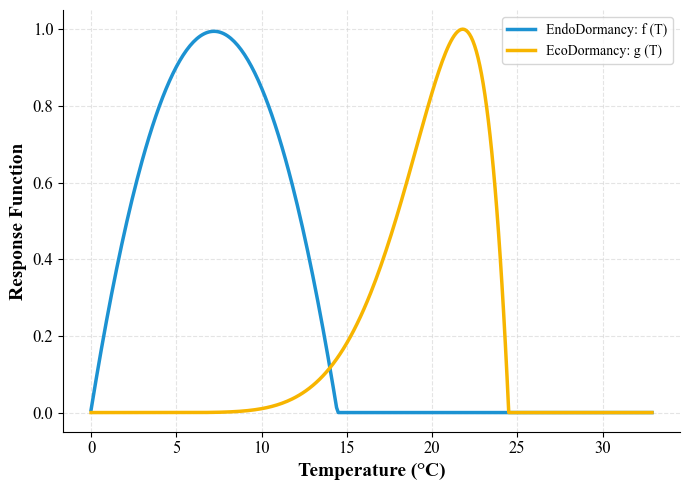

In [370]:
# Mean temperatures
MeanT = np.arange(0, 33, .1)    

a = -0.01898898919885883
b = 0.273859610005452
c = 0.006997020440018598
endoTempResponse = EndoTempResponse(MeanT,a,b,c)


# EcoDormancy model parameters
MinTemp = 3.79
OptTemp = 21.8
MaxTemp = 24.5
RefTemp = 21.8
ecoTempResponse = wangengel(MinTemp, OptTemp, MaxTemp, RefTemp, MeanT)

plt.figure(figsize=(7,5))

plt.plot(MeanT, endoTempResponse, label='EndoDormancy: f (T)', color=color1, linewidth=2.5)
plt.plot(MeanT, ecoTempResponse, label='EcoDormancy: g (T)', color=color2, linewidth=2.5)

plt.legend(prop=font_legend)

plt.xlabel("Temperature (°C)", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Response Function", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)

# for spine in plt.gca().spines.values():
#     spine.set_linewidth(1.2)

plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/ChillHeatTT.png", dpi=600, bbox_inches='tight')


plt.show()

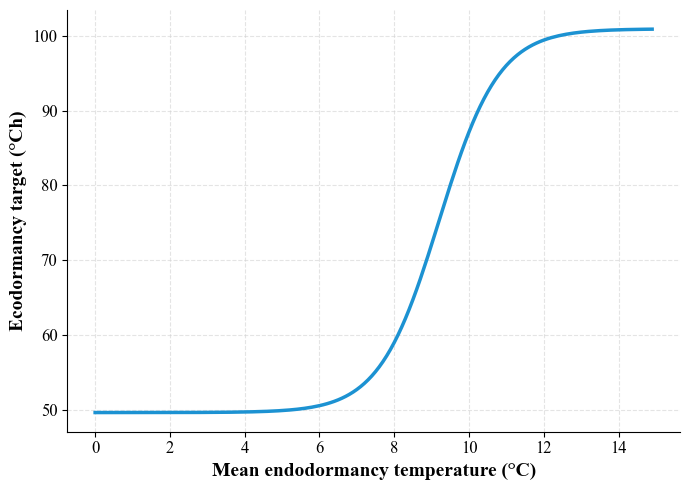

In [371]:
# Mean temperatures
MeanT = np.arange(0, 15, .1)  
Target = 101.29
y_min = 0.4901185445285534
y_max = 0.5063417939209804
k = 1.25#2.481340711095187
T_0 = 9.2#9.3

EcoTarget = Target*MeanEndoResponse(MeanT,y_min,y_max,k,T_0)

plt.figure(figsize=(7,5))
plt.plot(MeanT,EcoTarget, color=color1, linewidth=2.5)

# plt.legend(prop=font_legend)

plt.xlabel("Mean endodormancy temperature (°C)", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Ecodormancy target (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)

# for spine in plt.gca().spines.values():
#     spine.set_linewidth(1.2)

plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/HeatTarget.png", dpi=600, bbox_inches='tight')


plt.show()

1286.9  < Max 0.75 <  1373.6000000000001


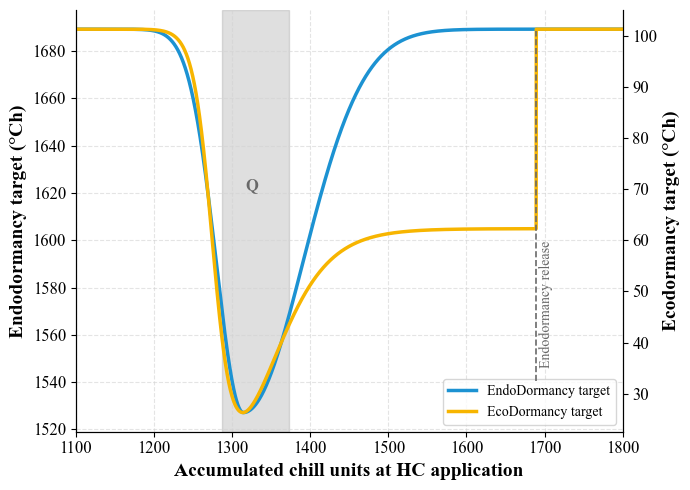

In [509]:
# Chill Units at HC
chillsAtHC = np.arange(0, 1800, .1)  
UntreatedEndoTarget = 1689.3
UntreatedEcoTarget = 101.29

# asymmetric gaussian for HCChillSensitivity
a = 0.0960
u = 1314.54
sigma_l = 34.72 
sigma_r = 76.498

HCChillSensitivity = UntreatedEndoTarget*asym_gauss(chillsAtHC,a,u,sigma_l, sigma_r)

# DOUBLE SIGMOID for HCHeatSensitivity
a_drop= 0.873576094258      # magnitude of sharp drop
a_rec= 0.48833106     # magnitude of recovery
k_rec= 25.98592      # recovery steepness
delta_k= 55.135035     # extra steepness for drop (k_drop = k_rec + delta_k)
x_drop= 1.27499   # drop midpoint
delta_x= 0.050    # delay between drop and recovery
nu = 1.9  

chillsAtHC_scaled = chillsAtHC / 1000 # Scaled because x data was previously scaled by 1000 during parameter estimation
HCHeatSensitivity = [UntreatedEcoTarget*double_sigmoid_constrained(unit, a_drop, a_rec, k_rec, delta_k, x_drop, delta_x, nu) if unit<=UntreatedEndoTarget/1000 else UntreatedEcoTarget for unit in chillsAtHC_scaled]


plt.figure(figsize=(7,5))

# --- PRIMARY AXIS (Left Y-axis) ---
ax1 = plt.gca()
ln1 = ax1.plot(chillsAtHC, HCChillSensitivity, 
               color=color1, linewidth=2.5, 
               label='EndoDormancy target')

ax1.set_xlabel("Accumulated chill units at HC application", 
               fontsize=14, fontweight="bold", font=font_tick)

ax1.set_ylabel("Endodormancy target (°Ch)", 
               fontsize=14, fontweight="bold", font=font_tick)

ax1.tick_params(axis='both', labelsize=12)
plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

ax1.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)
ax1.spines['top'].set_visible(False)

# Shaded area with max HC effect
Delta_endo = np.max(HCChillSensitivity)-np.min(HCChillSensitivity)
Dela_eco = np.max(HCHeatSensitivity)-np.min(HCHeatSensitivity)
mixed_sensitivity_effect = HCChillSensitivity+HCHeatSensitivity
max_effect_locs = np.where(mixed_sensitivity_effect<(np.max(mixed_sensitivity_effect) - 0.75*(Delta_endo+Dela_eco)))[0]
x0 = chillsAtHC[max_effect_locs[0]]
x1 = chillsAtHC[max_effect_locs[-1]]
ax1.axvspan(x0, x1, color='gray', alpha=0.25)
print(x0,' < Max 0.75 < ',x1)
ax1.text(.495*(x0+x1), 1620, 'Q', color='dimgrey', rotation=0, va='bottom', fontweight="bold",fontproperties=font_tick)


# --- SECONDARY AXIS (Right Y-axis) ---
ax2 = ax1.twinx()   # create right y-axis
ln2 = ax2.plot(chillsAtHC, HCHeatSensitivity, 
               color=color2, linewidth=2.5, 
               label='EcoDormancy target')

ax2.set_ylabel("Ecodormancy target (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

ax2.tick_params(axis='y', labelsize=12)
plt.yticks(fontproperties=font_tick)

# Endo target
ax2.axvline(x=1689, ymin=0.12, ymax=0.95, color='dimgray', linestyle='--', linewidth=1.2)
ax2.text(1693, 35, "Endodormancy release", color='dimgrey', rotation=90, va='bottom', fontproperties=font_legend)


# --- COMBINED LEGEND ---
lns = ln1 + ln2
labels = [l.get_label() for l in lns]
ax1.legend(lns, labels, prop=font_legend, loc='lower right')

plt.xlim(1100,1800)
plt.gca().spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/HCresponse.png", dpi=600, bbox_inches='tight')
plt.show()


C:\Users\HRANFS\AppData\Local\Temp\ipykernel_27992\2976885717.py:87: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\HRANFS\AppData\Local\Temp\ipykernel_27992\2976885717.py:134: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


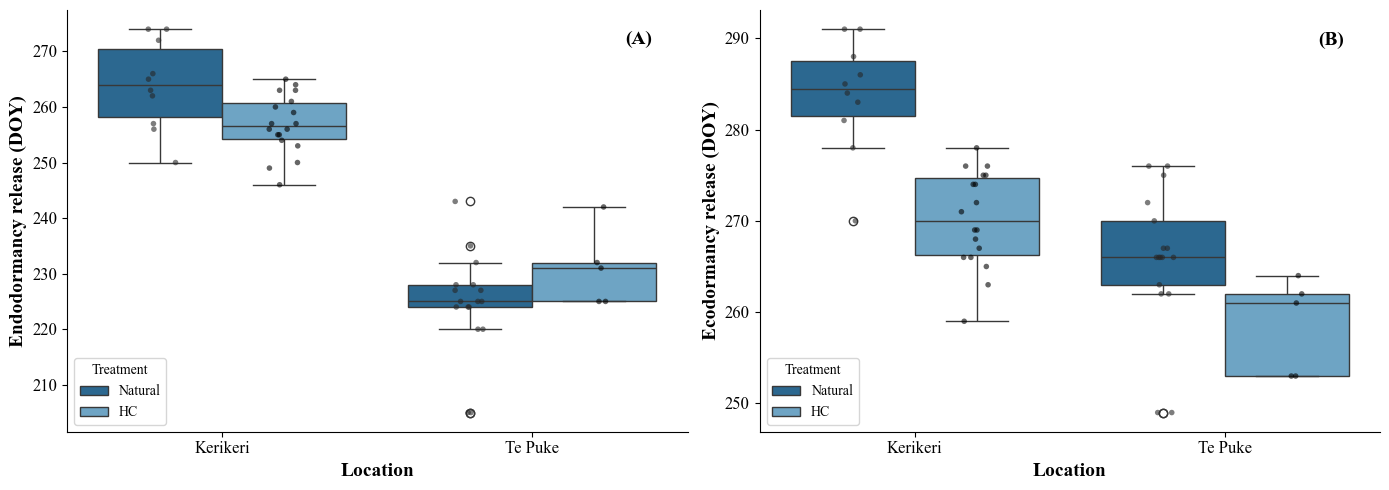

In [373]:
# Endodormancy End DOY
AccumulatedChilling = Report['KiwiFruit.Phenology.AccumulatedChilling']
BudBurstDOY = Report['KiwiFruit.Phenology.BudBurstDOY']
DOY = Report['Clock.Today.DayOfYear']

BBControl_mask = (Report['FolderName'] == 'BBControl')
BBHC_mask = (Report['FolderName'] == 'BBHC')
BBControl_id = Report.loc[BBControl_mask, 'SimulationID'].unique()
BBHC_id = Report.loc[BBHC_mask, 'SimulationID'].unique()


ObservedBB_unique = ObservedBB.groupby('SimulationName', sort=False).head(1)
ObservedBB_unique = ObservedBB_unique[ObservedBB_unique['SimulationID'].isin(BBControl_id)]

ObservedBBHC_unique = ObservedBBHC.groupby('SimulationName', sort=False).head(1)
ObservedBBHC_unique = ObservedBBHC_unique[ObservedBBHC_unique['SimulationID'].isin(BBHC_id)]

def progression_end_doy(
    Report,
    DOY,
    progress,
    target_sim_ids,
    target_years):

    results = []

    for sim_id,year in zip(target_sim_ids,target_years):
        mask = (
            (Report['SimulationID'] == sim_id) &
            (Report['Clock.Today.Year'] == year)
        )

        # Skip if this SimulationID–Year combo does not exist
        if not mask.any():
            continue

        idx_max = np.argmax(progress[mask])
        doy_end = DOY[mask].iloc[idx_max]

        results.append({
            'SimulationID': sim_id,
            'Year': year,
            'EndDOY': doy_end
        })

    return pd.DataFrame(results)


EndoEndBB = progression_end_doy(Report, DOY, AccumulatedChilling, BBControl_id, ObservedBB_unique['Clock.Today.Year'])
EndoEndBBHC = progression_end_doy(Report, DOY, AccumulatedChilling, BBHC_id, ObservedBBHC_unique['Clock.Today.Year'])
EcoEndBB = progression_end_doy(Report, DOY, BudBurstDOY, BBControl_id, ObservedBB_unique['Clock.Today.Year'])
EcoEndBBHC = progression_end_doy(Report, DOY, BudBurstDOY, BBHC_id, ObservedBBHC_unique['Clock.Today.Year'])

info_dict_endo = pd.DataFrame({'id':[i for i in BBControl_id]+[i for i in BBHC_id],
                'treatment':['Natural' for i in BBControl_id]+['HC' for i in BBHC_id],
                'loc':[i for i in ObservedBB_unique['Location']]+[i for i in ObservedBBHC_unique['Location']],
                'year':[i for i in ObservedBB_unique['Clock.Today.Year']]+[i for i in ObservedBBHC_unique['Clock.Today.Year']],
                'endday':[i for i in EndoEndBB['EndDOY']]+[i for i in EndoEndBBHC['EndDOY']]})

info_dict_eco = pd.DataFrame({'id':[i for i in BBControl_id]+[i for i in BBHC_id],
                'treatment':['Natural' for i in BBControl_id]+['HC' for i in BBHC_id],
                'loc':[i for i in ObservedBB_unique['Location']]+[i for i in ObservedBBHC_unique['Location']],
                'year':[i for i in ObservedBB_unique['Clock.Today.Year']]+[i for i in ObservedBBHC_unique['Clock.Today.Year']],
                'endday':[i for i in EcoEndBB['EndDOY']]+[i for i in EcoEndBBHC['EndDOY']]})



fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

palette = {'Natural': '#1C6BA0', 'HC': '#5FA8D3'}

# ==========================
# Subplot 1: Endodormancy
# ==========================
ax1 = axes[0]

sns.boxplot(
    data=info_dict_endo,
    x='loc',
    y='endday',
    hue='treatment',
    palette=palette,
    linewidth=1,
    ax=ax1
)

sns.stripplot(
    data=info_dict_endo,
    x='loc',
    y='endday',
    hue='treatment',
    dodge=True,
    color='black',
    alpha=0.6,
    size=4,
    ax=ax1
)

ax1.set_xlabel("Location", fontsize=14, fontweight="bold", fontproperties=font_tick)
ax1.set_ylabel("Endodormancy release (DOY)", fontsize=14, fontweight="bold", fontproperties=font_tick)

# Legend (fix duplication)
handles, labels = ax1.get_legend_handles_labels()
leg1 = ax1.legend(
    handles[:2], labels[:2],
    title='Treatment',
    prop=font_legend,
    frameon=True
)
leg1.get_title().set_fontproperties(font_legend)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both')
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontproperties(font_tick)


# ==========================
# Subplot 2: Ecodormancy
# ==========================
ax2 = axes[1]

sns.boxplot(
    data=info_dict_eco,       # <- DIFFERENT DATAFRAME
    x='loc',
    y='endday',
    hue='treatment',
    palette=palette,
    linewidth=1,
    ax=ax2
)

sns.stripplot(
    data=info_dict_eco,       # <- DIFFERENT DATAFRAME
    x='loc',
    y='endday',
    hue='treatment',
    dodge=True,
    color='black',
    alpha=0.6,
    size=4,
    ax=ax2
)

ax2.set_xlabel("Location", fontsize=14, fontweight="bold", fontproperties=font_tick)
ax2.set_ylabel("Ecodormancy release (DOY)", fontsize=14, fontweight="bold", fontproperties=font_tick)

# Legend (same handling)
handles, labels = ax2.get_legend_handles_labels()
leg2 = ax2.legend(
    handles[:2], labels[:2],
    title='Treatment',
    prop=font_legend,
    frameon=True
)
leg2.get_title().set_fontproperties(font_legend)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='both')
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontproperties(font_tick)


ax1.text(0.9, 0.95, '(A)', transform=ax1.transAxes,
        fontsize=14, fontweight='bold', va='top', font=font_tick)

ax2.text(0.9, 0.95, '(B)', transform=ax2.transAxes,
        fontsize=14, fontweight='bold', va='top', font=font_tick)


plt.tight_layout()
plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/boxEndoEcoHC.png", dpi=600, bbox_inches='tight')

plt.show()




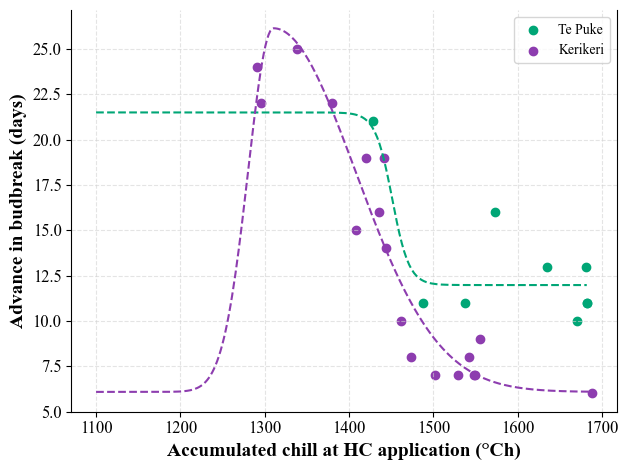

In [538]:
# HC advanced BB days
ChillingAtHC = Report['KiwiFruit.Phenology.ChillingAtHC']
BudBurstDOY_HC = Report['KiwiFruit.Phenology.BudBurstDOY']
DOY = Report['Clock.Today.DayOfYear']

BBHC_mask = (Report['FolderName'] == 'BBHC')
BBHC_id = Report.loc[BBHC_mask, 'SimulationID'].unique()

ObservedBBHC_unique = ObservedBBHC.groupby('SimulationName', sort=False).head(1)
ObservedBBHC_unique = ObservedBBHC_unique[ObservedBBHC_unique['SimulationID'].isin(BBHC_id)]

def progression_end_doy(
    Report,
    ChillingAtHC,
    BudBurstDOY_HC,
    target_sim_ids,
    target_years):

    results = []

    for sim_id,year in zip(target_sim_ids,target_years):
        mask = (
            (Report['SimulationID'] == sim_id) &
            (Report['Clock.Today.Year'] == year)
        )

        # Skip if this SimulationID–Year combo does not exist
        if not mask.any():
            continue

        target_BudBurstDOY_HC = np.max(BudBurstDOY_HC[mask])
        target_ChillingAtHC = ChillingAtHC[mask].iloc[-1]
        target_SimulationName = np.max(Report['SimulationName'][mask])

        results.append({
            'SimulationID': sim_id,
            'Year': year,
            'BudBurstDOY_HC': target_BudBurstDOY_HC,
            'chillingAtHC': target_ChillingAtHC,
            'SimulationName': target_SimulationName
        })

    return pd.DataFrame(results)


BBHC_doy = progression_end_doy(Report, ChillingAtHC, BudBurstDOY_HC, BBHC_id, ObservedBBHC_unique['Clock.Today.Year'])

info_dict_BBHC = pd.DataFrame({'id':[i for i in BBHC_id]+[73,74,75,76],
                'treatment':['HC' for i in BBHC_id]+['HC','HC','HC','HC'],
                'loc':[i for i in ObservedBBHC_unique['Location']]+['Te Puke','Te Puke','Te Puke','Te Puke'],
                'year':[i for i in ObservedBBHC_unique['Clock.Today.Year']]+[2015,2015,2015,2015],
                # Manually deactivaing the HC application in APSIM simulations to get the natural BudBurstDOY
                'BudBurstDOY':[285,278,278,281,281,281,281,281,266,266,291,291,291,272,272,291,291,275,270,284,284,283,286,276,276,276,276],
                'BudBurstDOY_HC':[i for i in BBHC_doy['BudBurstDOY_HC']]+[255,260,265,265],
                'chillingAtHC':[i for i in BBHC_doy['chillingAtHC']]+[1428,1573,1682,1682],
                'SimulationName':[i for i in BBHC_doy['SimulationName']]+['HaywardTPBBHCT1','HaywardTPBBHCT2','HaywardTPBBHCT3','HaywardTPBBHCT4']})



info_dict_BBHC_TP = info_dict_BBHC[info_dict_BBHC['loc']=='Te Puke']
info_dict_BBHC_KK = info_dict_BBHC[info_dict_BBHC['loc']=='Kerikeri']

#### Fitting reverse sigmoids
def reverse_sigmoid(x,y_min,y_max,k,x0):
    return y_min + (y_max-y_min)/(1+np.exp(k*(x-x0)))

x_tp = info_dict_BBHC_TP['chillingAtHC']
y_tp = info_dict_BBHC_TP['BudBurstDOY']-info_dict_BBHC_TP['BudBurstDOY_HC']
bounds_A = ([10, 14, 0, 1300],
            [13, 21.5, 0.1, 1800])
popt_A, _ = curve_fit(reverse_sigmoid, x_tp, y_tp, bounds=bounds_A, maxfev=20000)
x_tp_fit = np.linspace(1100, x_tp.max(), 200)
y_tp_fit = reverse_sigmoid(x_tp_fit, popt_A[0], popt_A[1], popt_A[2], popt_A[3])
plt.plot(x_tp_fit,y_tp_fit,'--', color=color3)


x_kk = info_dict_BBHC_KK['chillingAtHC']
y_kk = info_dict_BBHC_KK['BudBurstDOY']-info_dict_BBHC_KK['BudBurstDOY_HC']
bounds_B = ([-22, 1250,  25,  90, 5],
            [-18, 1320, 30, 100, 8])
popt_B, _ = curve_fit(asym_gauss, x_kk, y_kk, bounds=bounds_B, maxfev=20000)
x_kk_fit = np.linspace(1100, x_kk.max(), 300)
y_kk_fit = asym_gauss(x_kk_fit, popt_B[0], popt_B[1], popt_B[2], popt_B[3], popt_B[4])
plt.plot(x_kk_fit,y_kk_fit,'--', color=color4)


plt.scatter(x=info_dict_BBHC_TP['chillingAtHC'], y=info_dict_BBHC_TP['BudBurstDOY']-info_dict_BBHC_TP['BudBurstDOY_HC'],label='Te Puke', color=color3)
plt.scatter(x=info_dict_BBHC_KK['chillingAtHC'], y=info_dict_BBHC_KK['BudBurstDOY']-info_dict_BBHC_KK['BudBurstDOY_HC'], label='Kerikeri', color=color4)
plt.legend(prop=font_legend, loc='upper right')
plt.ylabel('Advance in budbreak (days)', font=font_tick, fontsize=14, fontweight="bold")
plt.xlabel('Accumulated chill at HC application (°Ch)', font=font_tick, fontsize=14, fontweight="bold")

plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)
plt.gca().spines['top'].set_visible(False)
plt.tight_layout()
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/advanceDaysBB.png", dpi=600, bbox_inches='tight')
plt.show()

C:\Users\HRANFS\AppData\Local\Temp\ipykernel_27992\149452409.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Location", "HC_window"])
C:\Users\HRANFS\AppData\Local\Temp\ipykernel_27992\149452409.py:43: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


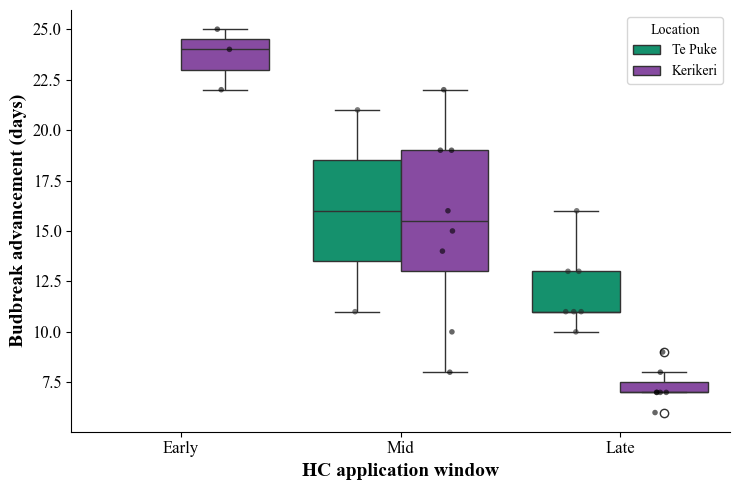

   Location HC_window  n  median       mean  iqr
0  Kerikeri     Early  3    24.0  23.666667  1.5
1  Kerikeri       Mid  8    15.5  15.375000  6.0
2  Kerikeri      Late  7     7.0   7.285714  0.5
3   Te Puke     Early  0     NaN        NaN  NaN
4   Te Puke       Mid  2    16.0  16.000000  5.0
5   Te Puke      Late  7    11.0  12.142857  2.0


In [552]:

df = pd.DataFrame({
    "HC_units": np.concatenate([x_tp, x_kk]),
    "Budbreak_advance": np.concatenate([y_tp, y_kk]),
    "Location": (["Te Puke"] * len(x_tp)) + (["Kerikeri"] * len(x_kk))
})


bins = [1200, 1350, 1500, 1700]
labels = ["Early", "Mid", "Late"]

df["HC_window"] = pd.cut(
    df["HC_units"],
    bins=bins,
    labels=labels,
    right=False
)


summary = (
    df.groupby(["Location", "HC_window"])
      .agg(
          n=("Budbreak_advance", "count"),
          median=("Budbreak_advance", "median"),
          mean=("Budbreak_advance", "mean"),
          iqr=("Budbreak_advance",
               lambda x: x.quantile(0.75) - x.quantile(0.25))
      )
      .reset_index()
)


plt.figure(figsize=(7.5, 5))

sns.boxplot(
    data=df,
    x="HC_window",
    y="Budbreak_advance",
    hue="Location",
    palette={"Te Puke": color3, "Kerikeri": color4},
    linewidth=1
)

sns.stripplot(
    data=df,
    x="HC_window",
    y="Budbreak_advance",
    hue="Location",
    dodge=True,
    color="black",
    alpha=0.6,
    size=4
)

plt.xlabel("HC application window", font=font_tick, fontsize=14, fontweight="bold")
plt.ylabel("Budbreak advancement (days)", font=font_tick, fontsize=14, fontweight="bold")

# Fix duplicate legend caused by boxplot + stripplot
handles, labels_ = plt.gca().get_legend_handles_labels()
leg = plt.legend(
    handles[:2],
    labels_[:2],
    title="Location",
    prop=font_legend,
    frameon=True
)
leg.get_title().set_fontproperties(font_legend)

plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/advanceDaysBB.png", dpi=600, bbox_inches='tight')
plt.show()

print(summary)

In [ ]:
# Endodormancy progression
AccumulatedChilling = Report['KiwiFruit.Phenology.AccumulatedChilling']
DOY = Report['Clock.Today.DayOfYear']
Dates = Report['Clock.Today']
START_DOY=59


# SimulationName = HaywardBB2014Control (KK)
simulation28 = (Report['SimulationID'] == 28) & (Report['Clock.Today.Year'] == 2014)
# SimulationName = HaywardBB2019Untreatedcontrol (KK)
simulation17 = (Report['SimulationID'] == 17) & (Report['Clock.Today.Year'] == 2019)
# SimulationName = HaywardKKBBControl (KK)
simulation4 = (Report['SimulationID'] == 4) & (Report['Clock.Today.Year'] == 2015)
# SimulationName = HWBBRaw2020Control (KK)
simulation18 = (Report['SimulationID'] == 18) & (Report['Clock.Today.Year'] == 2020)

# SimulationName = HaywardTPBBCon1 (TP)
simulation2 = (Report['SimulationID'] == 2) & (Report['Clock.Today.Year'] == 2015)
# SimulationName = HW-Budbreak-TP2020Control (TP)
simulation22 = (Report['SimulationID'] == 22) & (Report['Clock.Today.Year'] == 2020)
# SimulationName = HWBBRawTP2021Control (TP)
simulation21 = (Report['SimulationID'] == 21) & (Report['Clock.Today.Year'] == 2021)
# SimulationName = HWBBTP2022Control (TP)
simulation26 = (Report['SimulationID'] == 27) & (Report['Clock.Today.Year'] == 2022)



mask28_endo = (DOY[simulation28] <= 265)
mask28_eco1  = (DOY[simulation28] <= 286) 
mask28_eco2  = (DOY[simulation28] >= 165)

mask17_endo = (DOY[simulation17] <= 256)
mask17_eco1  = (DOY[simulation17] <= 278) 
mask17_eco2  = (DOY[simulation17] >= 165)

mask4_endo = (DOY[simulation4] <= 257)
mask4_eco1  = (DOY[simulation4] <= 282) 
mask4_eco2  = (DOY[simulation4] >= 165)

mask2_endo = (DOY[simulation2] <= 228)
mask2_eco1  = (DOY[simulation2] <= 275) 
mask2_eco2  = (DOY[simulation2] >= 165)

mask22_endo = (DOY[simulation22] <= 224)
mask22_eco1  = (DOY[simulation22] <= 267) 
mask22_eco2  = (DOY[simulation22] >= 165)

mask18_endo = (DOY[simulation18] <= 273)
mask18_eco1  = (DOY[simulation18] <= 291) 
mask18_eco2  = (DOY[simulation18] >= 165)

mask21_endo = (DOY[simulation21] <= 231)
mask21_eco1  = (DOY[simulation21] <= 274) 
mask21_eco2  = (DOY[simulation21] >= 165)

mask27_endo = (DOY[simulation26] <= 243)
mask27_eco1  = (DOY[simulation26] <= 275) 
mask27_eco2  = (DOY[simulation26] >= 165)



EndoProgress28 = AccumulatedChilling[simulation28].copy()
EndoProgress17 = AccumulatedChilling[simulation17].copy()
EndoProgress4 = AccumulatedChilling[simulation4].copy()
EndoProgress2 = AccumulatedChilling[simulation2].copy()
EndoProgress22 = AccumulatedChilling[simulation22].copy()
EndoProgress18 = AccumulatedChilling[simulation18].copy()
EndoProgress21 = AccumulatedChilling[simulation21].copy()
EndoProgress27 = AccumulatedChilling[simulation26].copy()


plt.figure(figsize=(7,5))

plt.plot(DOY[simulation2][mask2_endo], EndoProgress2[mask2_endo], color='#1F3A5F', linewidth=2, linestyle='-', label='TP 2015')
plt.plot(DOY[simulation22][mask22_endo], EndoProgress22[mask22_endo], color='#1F3A5F', linewidth=2, linestyle='--',   label='TP 2020')
plt.plot(DOY[simulation21][mask21_endo], EndoProgress21[mask21_endo], color='#1F3A5F', linewidth=2, linestyle='-.',  label='TP 2021')
plt.plot(DOY[simulation26][mask27_endo], EndoProgress27[mask27_endo], color='#1F3A5F', linewidth=2, linestyle=':',   label='TP 2022')

plt.plot(DOY[simulation28][mask28_endo], EndoProgress28[mask28_endo], color='#2A9D8F', linewidth=2, linestyle='-', label='KK 2014')
plt.plot(DOY[simulation4][mask4_endo], EndoProgress4[mask4_endo], color='#2A9D8F', linewidth=2, linestyle='-.', label='KK 2015')
plt.plot(DOY[simulation17][mask17_endo], EndoProgress17[mask17_endo], color='#2A9D8F', linewidth=2, linestyle='--', label='KK 2019')
plt.plot(DOY[simulation18][mask18_endo], EndoProgress18[mask18_endo], color='#2A9D8F', linewidth=2, linestyle=':',  label='KK 2020')



plt.legend(prop=font_legend)
plt.title("Endodormancy progression", fontsize=14, fontweight="bold", font=font_tick)
plt.xlabel("Date", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Accumulated chill units (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
# Month-start ticks
month_start_mask = Dates[simulation28].dt.day == 1
xticks = Dates[simulation28].dt.dayofyear[month_start_mask]
xtick_labels = Dates[simulation28].dt.strftime('%b')[month_start_mask]
#  KEEP ONLY ticks within x-limits
mask_in_range = (xticks >= 59) & (xticks <= 280)
xticks = xticks[mask_in_range]
xtick_labels = xtick_labels[mask_in_range]


plt.xlim(59,280)
plt.xticks(xticks, xtick_labels, fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/simulationsEndoNatural.png", dpi=600, bbox_inches='tight')


plt.show()

In [ ]:
# Ecodormancy progression
AccumulatedChilling = Report['KiwiFruit.Phenology.AccumulatedChilling']
EcoDormancyProgressThroughPhase = Report['KiwiFruit.Phenology.EcoDormancy.ProgressThroughPhase']
DOY = Report['Clock.Today.DayOfYear']
Dates = Report['Clock.Today']
START_DOY=59


# SimulationName = HaywardBB2014Control (KK)
simulation28 = (Report['SimulationID'] == 28) & (Report['Clock.Today.Year'] == 2014)
# SimulationName = HaywardBB2019Untreatedcontrol (KK)
simulation17 = (Report['SimulationID'] == 17) & (Report['Clock.Today.Year'] == 2019)
# SimulationName = HaywardKKBBControl (KK)
simulation4 = (Report['SimulationID'] == 4) & (Report['Clock.Today.Year'] == 2015)
# SimulationName = HWBBRaw2020Control (KK)
simulation18 = (Report['SimulationID'] == 18) & (Report['Clock.Today.Year'] == 2020)

# SimulationName = HaywardTPBBCon1 (TP)
simulation2 = (Report['SimulationID'] == 2) & (Report['Clock.Today.Year'] == 2015)
# SimulationName = HW-Budbreak-TP2020Control (TP)
simulation22 = (Report['SimulationID'] == 22) & (Report['Clock.Today.Year'] == 2020)
# SimulationName = HWBBRawTP2021Control (TP)
simulation21 = (Report['SimulationID'] == 21) & (Report['Clock.Today.Year'] == 2021)
# SimulationName = HWBBTP2022Control (TP)
simulation26 = (Report['SimulationID'] == 27) & (Report['Clock.Today.Year'] == 2022)



mask28_endo = (DOY[simulation28] <= 265)
mask28_eco1  = (DOY[simulation28] <= 286) 
mask28_eco2  = (DOY[simulation28] >= 165)

mask17_endo = (DOY[simulation17] <= 256)
mask17_eco1  = (DOY[simulation17] <= 278) 
mask17_eco2  = (DOY[simulation17] >= 165)

mask4_endo = (DOY[simulation4] <= 257)
mask4_eco1  = (DOY[simulation4] <= 282) 
mask4_eco2  = (DOY[simulation4] >= 165)

mask2_endo = (DOY[simulation2] <= 228)
mask2_eco1  = (DOY[simulation2] <= 275) 
mask2_eco2  = (DOY[simulation2] >= 165)

mask22_endo = (DOY[simulation22] <= 224)
mask22_eco1  = (DOY[simulation22] <= 267) 
mask22_eco2  = (DOY[simulation22] >= 165)

mask18_endo = (DOY[simulation18] <= 273)
mask18_eco1  = (DOY[simulation18] <= 291) 
mask18_eco2  = (DOY[simulation18] >= 165)

mask21_endo = (DOY[simulation21] <= 231)
mask21_eco1  = (DOY[simulation21] <= 274) 
mask21_eco2  = (DOY[simulation21] >= 165)

mask27_endo = (DOY[simulation26] <= 243)
mask27_eco1  = (DOY[simulation26] <= 275) 
mask27_eco2  = (DOY[simulation26] >= 165)



EndoProgress28 = AccumulatedChilling[simulation28].copy()
EcoProgress28  = EcoDormancyProgressThroughPhase[simulation28].copy()
EndoProgress17 = AccumulatedChilling[simulation17].copy()
EcoProgress17  = EcoDormancyProgressThroughPhase[simulation17].copy()
EndoProgress4 = AccumulatedChilling[simulation4].copy()
EcoProgress4  = EcoDormancyProgressThroughPhase[simulation4].copy()
EndoProgress2 = AccumulatedChilling[simulation2].copy()
EcoProgress2  = EcoDormancyProgressThroughPhase[simulation2].copy()
EndoProgress22 = AccumulatedChilling[simulation22].copy()
EcoProgress22  = EcoDormancyProgressThroughPhase[simulation22].copy()
EndoProgress18 = AccumulatedChilling[simulation18].copy()
EcoProgress18  = EcoDormancyProgressThroughPhase[simulation18].copy()
EndoProgress21 = AccumulatedChilling[simulation21].copy()
EcoProgress21  = EcoDormancyProgressThroughPhase[simulation21].copy()
EndoProgress27 = AccumulatedChilling[simulation26].copy()
EcoProgress27  = EcoDormancyProgressThroughPhase[simulation26].copy()

# Set values outside of mask to zero
EcoProgress28[~mask28_eco2]   = 0
EcoProgress17[~mask17_eco2]   = 0
EcoProgress4[~mask4_eco2]   = 0
EcoProgress2[~mask2_eco2]   = 0
EcoProgress22[~mask22_eco2]   = 0
EcoProgress18[~mask18_eco2]   = 0
EcoProgress21[~mask21_eco2]   = 0
EcoProgress27[~mask27_eco2]   = 0


plt.figure(figsize=(7,5))

plt.plot(DOY[simulation2][mask2_eco1], EcoProgress2[mask2_eco1], color='#1F3A5F', linewidth=2, linestyle='-', label='TP 2015')

plt.plot(DOY[simulation22][mask22_eco1], EcoProgress22[mask22_eco1], color='#1F3A5F', linewidth=2, linestyle='--',   label='TP 2020')

plt.plot(DOY[simulation21][mask21_eco1], EcoProgress21[mask21_eco1], color='#1F3A5F', linewidth=2, linestyle='-.',  label='TP 2021')

plt.plot(DOY[simulation26][mask27_eco1], EcoProgress27[mask27_eco1], color='#1F3A5F', linewidth=2, linestyle=':',   label='TP 2022')


plt.plot(DOY[simulation28][mask28_eco1], EcoProgress28[mask28_eco1], color='#2A9D8F', linewidth=2, linestyle='-', label='KK 2014')

plt.plot(DOY[simulation4][mask4_eco1], EcoProgress4[mask4_eco1], color='#2A9D8F', linewidth=2, linestyle='-.', label='KK 2015')

plt.plot(DOY[simulation17][mask17_eco1], EcoProgress17[mask17_eco1], color='#2A9D8F', linewidth=2, linestyle='--', label='KK 2019')

plt.plot(DOY[simulation18][mask18_eco1], EcoProgress18[mask18_eco1], color='#2A9D8F', linewidth=2, linestyle=':',  label='KK 2020')



plt.legend(prop=font_legend)
plt.title('Ecodormancy progression', font=font_tick)
plt.xlabel("Date", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Accumulated heat units (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
# Month-start ticks
month_start_mask = Dates[simulation28].dt.day == 1
xticks = Dates[simulation28].dt.dayofyear[month_start_mask]
xtick_labels = Dates[simulation28].dt.strftime('%b')[month_start_mask]
#  KEEP ONLY ticks within x-limits
mask_in_range = (xticks >= 210) & (xticks <= 295)
xticks = xticks[mask_in_range]
xtick_labels = xtick_labels[mask_in_range]


plt.xlim(210,295)
plt.xticks(xticks, xtick_labels, fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/simulationsEndoNatural.png", dpi=600, bbox_inches='tight')


plt.show()

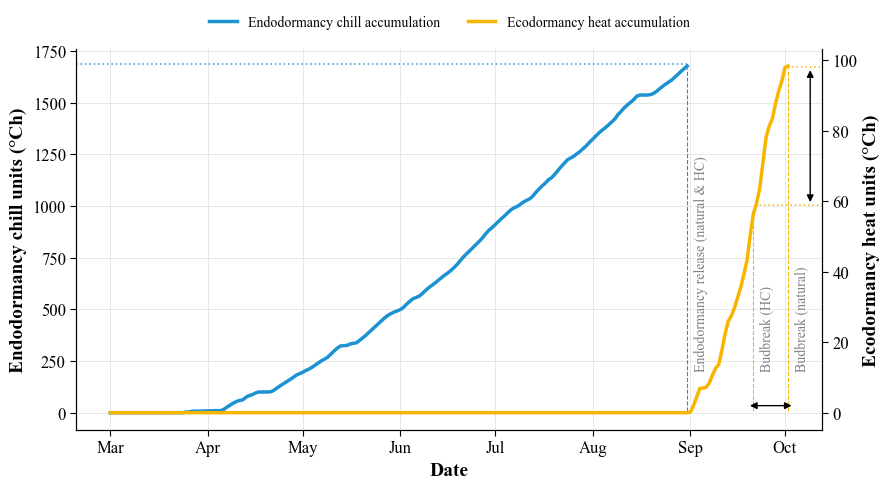

In [440]:
AccumulatedChilling = Report['KiwiFruit.Phenology.AccumulatedChilling']
EcoDormancyProgressThroughPhase = Report['KiwiFruit.Phenology.EcoDormancy.ProgressThroughPhase']
DOY = Report['Clock.Today.DayOfYear']
Dates = Report['Clock.Today']

START_DOY = 59
# SimulationName = HWBBTP2022Control
simulation26 = (Report['SimulationID'] == 26) & (Report['Clock.Today.Year'] == 2022)
# SimulationName = HWBBTP2022HC225
simulation71 = (Report['SimulationID'] == 71) & (Report['Clock.Today.Year'] == 2022)
x = DOY[simulation26][START_DOY:]
Dates = pd.to_datetime(Dates[simulation26][START_DOY:])

mask_endo26 = (DOY[simulation26] <= 243)
mask_eco26a  = (DOY[simulation26] >= 165)
mask_eco26b  = (DOY[simulation26] <= 275) 

EndoProgress26 = AccumulatedChilling[simulation26][START_DOY:].copy()
EcoProgress26  = EcoDormancyProgressThroughPhase[simulation26][START_DOY:].copy()

EndoProgress71 = AccumulatedChilling[simulation71][START_DOY:].copy()
EcoProgress71  = EcoDormancyProgressThroughPhase[simulation71][START_DOY:].copy()

# Set values outside of mask to zero or nan
EndoPlot = EndoProgress26.copy()
EndoPlot[~mask_endo26] = np.nan

EcoPlot = EcoProgress26.copy()
EcoPlot[~mask_eco26a] = 0
EcoPlot[~mask_eco26b] = np.nan

Dates[~mask_eco26b] = np.nan

fig, ax = plt.subplots(figsize=(9,5))

# ---- Left axis: Endodormancy ----
ln1, = ax.plot(
    x, EndoPlot, color=color1, linewidth=2.5,
    label='Endodormancy chill accumulation'
)

ax.set_ylabel(
    "Endodormancy chill units (°Ch)",
    fontsize=14, fontweight="bold", fontproperties=font_tick
)

# Endo target (Natural)
ax.axhline(
    1689, xmax=0.82,
    color=color1, linestyle=':', linewidth=1.2, alpha=0.8
)
# Endo target (HC)
# ax.axhline(
#     1663.92, xmax=0.82,
#     color=color1, linestyle=':', linewidth=1.2, alpha=0.8
# )
# ---- Right axis: Ecodormancy ----
ax2 = ax.twinx()

ln2, = ax2.plot(
    x, EcoPlot, color=color2, linewidth=2.5,
    label='Ecodormancy heat accumulation'
)

ax2.set_ylabel(
    "Ecodormancy heat units (°Ch)",
    fontsize=14, fontweight="bold", fontproperties=font_tick
)

# Eco target (Natural)
ax2.axhline(
    98, xmin=0.96, xmax=1,
    color=color2, linestyle=':', linewidth=1.2, alpha=0.8
)
# Eco target (HC)
ax2.axhline(
    58.98, xmin=0.91, xmax=1,
    color=color2, linestyle=':', linewidth=1.2, alpha=0.8
)

# ---- Shared vertical event markers (draw ONLY on ax) ----
# ax.axvline(243, ymin=0.05, ymax=1, color='gray', linestyle='--', linewidth=0.8)
ax.text(245, 200, "Endodormancy release (natural & HC)", color='gray', rotation=90, va='bottom', fontproperties=font_legend)
ax.text(266, 200, "Budbreak (HC)", color='gray', rotation=90, va='bottom', fontproperties=font_legend)
ax.text(277, 200, "Budbreak (natural)", color='gray', rotation=90, va='bottom', fontproperties=font_legend)

ax.axvline(275, ymin=0.05, ymax=0.95, color=color2, linestyle='--', linewidth=0.8)
ax.axvline(264, ymin=0.05, ymax=0.55, color=color2, linestyle='--', linewidth=0.8)
ax.axvline(243, ymin=0.05, ymax=0.95, color=color1, linestyle='--', linewidth=0.8)
# ax.axvline(240, ymin=0.05, ymax=0.95, color=color1, linestyle='--', linewidth=0.8)



# ---- Arrows ----
ax2.annotate(
    "",
    xy=(277, 2),
    xytext=(262, 2),
    arrowprops=dict(
        arrowstyle="<|-|>",
        linewidth=1,
        color="black"
    )
)
ax2.annotate(
    "",
    xy=(282, 58.98),
    xytext=(282, 98),
    arrowprops=dict(
        arrowstyle="<|-|>",
        linewidth=1,
        color="black"
    )
)

# ---- X axis ----
ax.set_xlabel(
    "Date",
    fontsize=14, fontweight="bold", fontproperties=font_tick
)

month_start_mask = Dates.dt.day == 1
xticks = Dates.dt.dayofyear[month_start_mask]
xtick_labels = Dates.dt.strftime('%b')[month_start_mask]

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontproperties=font_tick)

for label in ax.get_yticklabels():
    label.set_fontproperties(font_tick)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_tick)


# ---- Legend (combined, outside, compact) ----
ax.legend(
    handles=[ln1, ln2],
    prop=font_legend,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

# ---- Grid & aesthetics ----
# ax.grid(axis='x', linewidth=0.6, color='lightgray', alpha=0.6)
ax.grid(linewidth=0.6, color='lightgray', alpha=0.6)


ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax.tick_params(width=0.8, length=4)
ax2.tick_params(width=0.8, length=4)


plt.tight_layout()    
plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/simulation71BB.png", dpi=600, bbox_inches='tight')

plt.show()

In [432]:
next((x for x in reversed(list(EcoProgress71)) if x != 0), None)

58.9801632093313

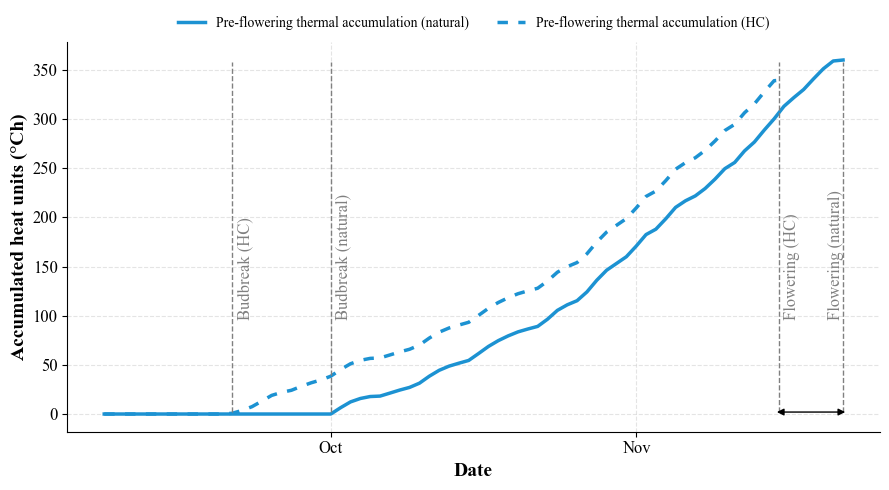

In [396]:
# EarlyLeafProgressThroughPhase
EarlyLeafProgressThroughPhase = Report['KiwiFruit.Phenology.EarlyLeaf.ProgressThroughPhase']
DOY = Report['Clock.Today.DayOfYear']
Dates = Report['Clock.Today']
START_DOY = 250

# SimulationName = HWBBTP2022Control
simulation26 = (Report['SimulationID'] == 26) & (Report['Clock.Today.Year'] == 2022)
# SimulationName = HWBBTP2022HC225
simulation71 = (Report['SimulationID'] == 71) & (Report['Clock.Today.Year'] == 2022)

x = DOY[simulation26][START_DOY:]
Dates = pd.to_datetime(Dates[simulation26][START_DOY:])

EarlyLeafProgressThroughPhase27  = EarlyLeafProgressThroughPhase[simulation26].copy()
EarlyLeafProgressThroughPhase71  = EarlyLeafProgressThroughPhase[simulation71].copy()

mask_27a  = (DOY[simulation26] >= 165)
mask_27b  = (DOY[simulation26] <= 326) 

mask_71a  = (DOY[simulation71] >= 165)
mask_71b  = (DOY[simulation71] <= 320) 

# Set values outside of mask to zero
EarlyLeafProgressThroughPhase27[~mask_27a]   = 0
EarlyLeafProgressThroughPhase71[~mask_71a]   = 0

Dates[~mask_27b] = np.nan

plt.figure(figsize=(9,5))

plt.plot(DOY[simulation26][mask_27b][250:], EarlyLeafProgressThroughPhase27[mask_27b][250:], color=color1, linewidth=2.5, label='Pre‑flowering thermal accumulation (natural)')
plt.plot(DOY[simulation71][mask_71b][250:], EarlyLeafProgressThroughPhase71[mask_71b][250:], color=color1, dashes=(3, 3), linewidth=2.5, label='Pre‑flowering thermal accumulation (HC)')

plt.axvline(x=326, ymin=.05, ymax=0.95, color='gray', linestyle='--', linewidth=1)
plt.text(324+.5, 100, "Flowering (natural)", color='gray', rotation=90, fontproperties=font_tick)

plt.axvline(x=319.5, ymin=.05, ymax=0.95, color='gray', linestyle='--', linewidth=1)
plt.text(320, 100, "Flowering (HC)", color='gray', rotation=90, fontproperties=font_tick)

plt.axvline(x=274, ymin=.05, ymax=0.95, color='gray', linestyle='--', linewidth=1)
plt.text(274+.5, 100, "Budbreak (natural)", color='gray', rotation=90, fontproperties=font_tick)

plt.axvline(x=264, ymin=.05, ymax=0.95, color='gray', linestyle='--', linewidth=1)
plt.text(264+.5, 100, "Budbreak (HC)", color='gray', rotation=90, fontproperties=font_tick)

# ---- Arrow annotation ----
# horizontal bidirecional arrow
plt.annotate(
    "",
    xy=(326.5, 2),
    xytext=(319, 2),
    arrowprops=dict(
        arrowstyle="<|-|>",
        linewidth=1,
        color="black"
    )
)


plt.legend(prop=font_legend,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1),
    ncol=2)

plt.xlabel("Date", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Accumulated heat units (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
month_start_mask = Dates.dt.day == 1
xticks = Dates.dt.dayofyear[month_start_mask]
xtick_labels = Dates.dt.strftime('%b')[month_start_mask]

plt.xticks(xticks)
plt.xticks(xticks, xtick_labels, fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/simulation26and71Flwring.png", dpi=600, bbox_inches='tight')


plt.show()

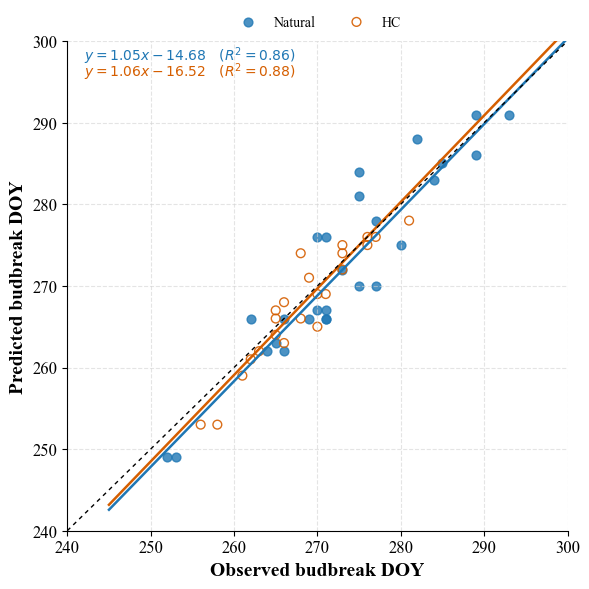

In [379]:
# BudBurstDOY
PredictedBudBurstDOY = PredictedObservedBB['Predicted.KiwiFruit.Phenology.BudBurstDOY']
ObservedBudBurstDOY = PredictedObservedBB['Observed.KiwiFruit.Phenology.BudBurstDOY']

PredictedBudBurstDOYHC = PredictedObservedBBHC['Predicted.KiwiFruit.Phenology.BudBurstDOY']
ObservedBudBurstDOYHC = PredictedObservedBBHC['Observed.KiwiFruit.Phenology.BudBurstDOY']

# Regressions
RegNatural = 1.05*np.array([245,300])-14.68
RegHC = 1.06*np.array([245,300])-16.52

plt.figure(figsize=(6,6))

plt.scatter(ObservedBudBurstDOY,PredictedBudBurstDOY,
           color="#1f77b4", edgecolor="#1f77b4",
           alpha=0.8, s=40, label="Natural")

plt.scatter(ObservedBudBurstDOYHC,PredictedBudBurstDOYHC,
           facecolors='none', edgecolors="#D55E00",
           alpha=0.9, s=40, label="HC")


plt.plot([245,300], RegNatural, color="#1f77b4", linewidth=1.8)
plt.plot([245,300], RegHC, color="#D55E00", linewidth=1.8)


# Natural regression equation
plt.text(
    242, 297,                        
    r"$y = 1.05x - 14.68 \quad (R^2 = 0.86)$",
    color="#1f77b4",
    fontsize=10,
    va="bottom",
)
# HC regression equation
plt.text(
    242, 295,                        
    r"$y = 1.06x - 16.52 \quad (R^2 = 0.88)$",
    color="#D55E00",
    fontsize=10,
    va="bottom"
)


plt.legend(prop=font_legend,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1),
    ncol=2)

plt.xlabel("Observed budbreak DOY", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Predicted budbreak DOY", fontsize=14, fontweight="bold", font=font_tick)

# Set axis limits
plt.xlim(240, 300)
plt.ylim(240, 300)

plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# 1:1 line
plt.plot([240,300],[240,300],color='k',dashes=(3, 3), linewidth=1)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/PredvsObsBB.png", dpi=600, bbox_inches='tight')


plt.show()

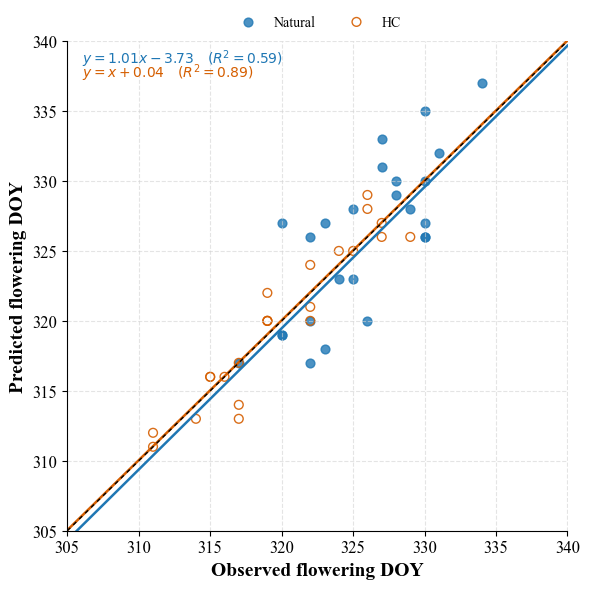

In [380]:
# FloweringDOY
PredictedBudFloweringDOY = PredictedObservedFlowering['Predicted.KiwiFruit.Phenology.FloweringDOY']
ObservedBudFloweringDOY = PredictedObservedFlowering['Observed.KiwiFruit.Phenology.FloweringDOY']

PredictedFloweringDOYHC = PredictedObservedFloweringHC['Predicted.KiwiFruit.Phenology.FloweringDOY']
ObservedFloweringDOYHC = PredictedObservedFloweringHC['Observed.KiwiFruit.Phenology.FloweringDOY']

# Regressions
axis_min=305
axis_max=340
RegNatural = 1.01*np.array([axis_min,axis_max])-3.73
RegHC = 1*np.array([axis_min,axis_max])+0.04

plt.figure(figsize=(6,6))

plt.scatter(ObservedBudFloweringDOY,PredictedBudFloweringDOY,
           color="#1f77b4", edgecolor="#1f77b4",
           alpha=0.8, s=40, label="Natural")

plt.scatter(ObservedFloweringDOYHC,PredictedFloweringDOYHC,
           facecolors='none', edgecolors="#D55E00",
           alpha=0.9, s=40, label="HC")


plt.plot([axis_min,axis_max], RegNatural, color="#1f77b4", linewidth=1.8)
plt.plot([axis_min,axis_max], RegHC, color="#D55E00", linewidth=1.8)


# Natural regression equation
plt.text(
    306, 338,                        
    r"$y = 1.01x - 3.73 \quad (R^2 = 0.59)$",
    color="#1f77b4",
    fontsize=10,
    va="bottom",
)
# HC regression equation
plt.text(
    306, 337,                        
    r"$y = x + 0.04 \quad (R^2 = 0.89)$",
    color="#D55E00",
    fontsize=10,
    va="bottom"
)


plt.legend(prop=font_legend,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1),
    ncol=2)

plt.xlabel("Observed flowering DOY", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Predicted flowering DOY", fontsize=14, fontweight="bold", font=font_tick)

# Set axis limits
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)

plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# 1:1 line
plt.plot([axis_min,axis_max],[axis_min,axis_max],color='k',dashes=(3, 3), linewidth=1)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/PredvsObsFlwr.png", dpi=600, bbox_inches='tight')


plt.show()

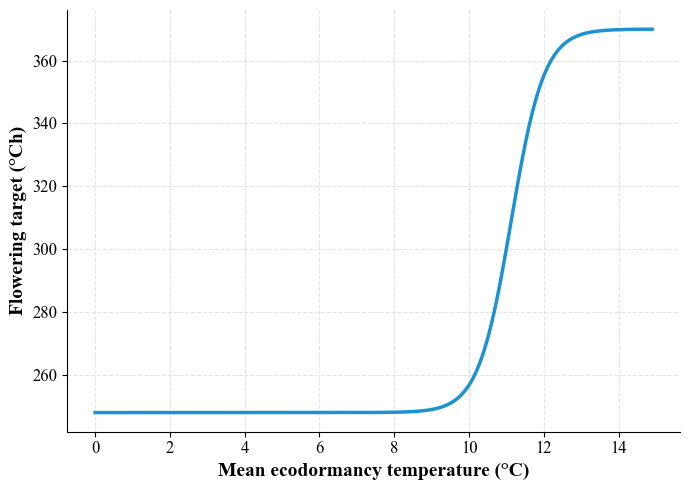

In [571]:
# Mean Eco dormancy temp affecting floweringDOY
weather_df = defaultdict(lambda: defaultdict(lambda: dict()))
weather_path= {'Kerikeri': "C:/Users/hranfs/Documents/VS code/Weather/Kerikeri_interpolated_hourly_2007_2024.csv",
                'Te Puke': "C:/Users/hranfs/Documents/VS code/Weather/Te Puke_interpolated_hourly_2007_2024.csv"}

MeanEndoTemp = []
MeanEcoTemp = []
BudBurstDOY = []
FloweringDOY = []
RequiredTT = []

for SimulationID in PredictedObservedFlowering['SimulationID']:
    
    year = PredictedObservedFlowering.loc[
        PredictedObservedFlowering['SimulationID'] == SimulationID,
        'Clock.Today.Year'].iloc[0]
    
    location = ObservedBB.loc[ObservedBB['SimulationID'] == SimulationID, 'Location'].iloc[0]
    
    # Predicted BudBurst day
    BudBurstDOY.append(PredictedObservedBB.loc[PredictedObservedBB['SimulationID'] == SimulationID, 'Predicted.KiwiFruit.Phenology.BudBurstDOY'].values[0])

    # Observed Flowering day
    FloweringDOY.append(PredictedObservedFlowering.loc[PredictedObservedFlowering['SimulationID'] == SimulationID, 'Observed.KiwiFruit.Phenology.FloweringDOY'].values[0])


    MeanEndoTemp.append(Report[(Report['SimulationID']==SimulationID) & 
           (Report['KiwiFruit.Phenology.CurrentStageName']=='EndChilling')  &
           (Report['Clock.Today.Year']==year)]['KiwiFruit.Phenology.MeanEndoTemp'].values[0])
    
    MeanEcoTemp.append(Report[(Report['SimulationID']==SimulationID) & 
           (Report['KiwiFruit.Phenology.CurrentStageName']=='BudBreak')  &
           (Report['Clock.Today.Year']==year)]['KiwiFruit.Phenology.MeanEcoTemp'].values[0])
    

    # Load the weather data
    weather_data = load_weather(weather_path[location], year)
    weather_since_start_doy = weather_data[(weather_data['doy']>=BudBurstDOY[-1]) & (weather_data['doy']<=FloweringDOY[-1])].reset_index(drop=True)  
    TT = 0
    for temp in weather_since_start_doy['temp']:
        TT += Wangengel(8.7,25.68,31.5,25.68,temp)
    
    RequiredTT.append(TT)



plt.figure(figsize=(7,5))

MeanT = np.arange(0,15,.1)
plt.plot(MeanT,370*MeanEndoResponse(MeanT,0.67,0.33,2.27,11.13), color=color1, linewidth=2.5)
# plt.scatter(MeanEcoTemp,np.divide(RequiredTT,355))

plt.xlabel("Mean ecodormancy temperature (°C)", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Flowering target (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/EcoTempOnFlowering.png", dpi=600, bbox_inches='tight')
plt.show()


